
# Computer Exercise 10.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.1 Monte Carlo Methods — *Estimation of Integrals and Areas*
> **풀이 일자**: Day 37
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **2.** Use a (pseudo)random-number generator to estimate (a) the number $\pi$ by the
> *dart-throwing* (hit-or-miss) method on the unit quarter circle, and (b) a definite
> integral $\int_0^1 g(x)\,dx$ by the *sample-mean* method. For a sequence of increasing
> sample sizes $N$, tabulate the estimate, the true error, and the estimated standard
> error $\hat\sigma/\sqrt N$, and verify graphically that the error decreases like
> $\mathcal{O}(N^{-1/2})$, independent of the integrand's smoothness.

### 한국어 풀이용 정리
난수로 적분을 추정하는 두 고전 기법 — **적중-실패(hit-or-miss)** 로 $\pi$ 추정,
**표본평균(sample-mean)** 으로 $\int_0^1 g\,dx$ 추정 — 을 구현한다. 핵심 메시지는
**오차가 $N^{-1/2}$ 로 줄어든다**(차원·매끄러움 무관)는 것과, 그 상수가 적분값의 *분산*으로 정해진다는 것.
사다리꼴/심프슨 같은 결정론적 공식과 달리 수렴이 느리지만 **고차원에서 역전**된다는 점을 예고한다.



## 2. 수학적 배경

### 2.1 표본평균 추정량
$I=\int_0^1 g(x)\,dx=\mathbb{E}[g(U)]$, $U\sim\mathrm{Unif}(0,1)$ 이므로
$$
\hat I_N=\frac1N\sum_{k=1}^N g(U_k),\qquad \mathbb{E}[\hat I_N]=I\ (\text{불편, unbiased}).
$$

### 2.2 표준오차와 $N^{-1/2}$ 법칙
$\sigma^2=\mathrm{Var}[g(U)]=\int_0^1 g^2-I^2$ 라 하면
$$
\boxed{\;
\mathrm{Var}[\hat I_N]=\frac{\sigma^2}{N}
\quad\Longrightarrow\quad
\text{표준오차 } \mathrm{SE}=\frac{\sigma}{\sqrt N}=\mathcal{O}(N^{-1/2}).
\;}
$$
중심극한정리(CLT)에 의해 $\hat I_N\approx \mathcal N(I,\sigma^2/N)$ 이고,
95% 신뢰구간은 $\hat I_N\pm 1.96\,\hat\sigma/\sqrt N$. $\hat\sigma^2$ 는 표본분산으로 추정한다.

### 2.3 적중-실패(hit-or-miss)로 $\pi$ 추정
사분원 $\{(x,y):x^2+y^2\le1,\ x,y\in[0,1]\}$ 의 넓이는 $\pi/4$.
$N$ 개의 균등 점 중 적중 비율 $\hat p$ 에 대해 $\hat\pi=4\hat p$.
$\hat p$ 는 이항분포라 $\mathrm{Var}[\hat\pi]=16\,p(1-p)/N=\mathcal{O}(N^{-1})$ → 표준오차 $\mathcal{O}(N^{-1/2})$.

### 2.4 결정론 공식과의 대비
사다리꼴 $\mathcal{O}(N^{-2})$, 심프슨 $\mathcal{O}(N^{-4})$ 은 1차원에서 훨씬 빠르다.
그러나 $d$ 차원에서 격자법은 $\mathcal{O}(N^{-r/d})$ 로 *차원의 저주*에 걸리는 반면,
몬테카를로는 **여전히 $N^{-1/2}$** — 고차원에서 결정론을 역전한다.



## 3. 풀이 흐름

1. **적중-실패 $\pi$**: $(x,y)\sim\mathrm{Unif}[0,1]^2$ 를 $N$ 개 뽑아 단위원 안 비율 $\times4$.
2. **표본평균 적분**: $g(x)=e^{-x^2}$ (참값 $\tfrac{\sqrt\pi}{2}\mathrm{erf}(1)$) 와
   $g(x)=\sqrt{1-x^2}$ (참값 $\pi/4$, 도함수 특이) 두 종류로 평균법 적용.
3. **표준오차**: 각 $N$ 에서 표본분산으로 $\hat\sigma/\sqrt N$ 을 계산.
4. **참오차 표**: 증가하는 $N=10^2,\dots,10^6$ 에서 추정값·참오차·표준오차·95% CI 포함 여부.
5. **수렴 그래프**: $\log N$ vs $\log|\text{error}|$ — 기울기 $-1/2$ 기준선과 비교.
6. **반복 분포**: 고정 $N$ 에서 추정을 여러 번 반복해 CLT 정규분포를 히스토그램으로 확인.
7. **해석**: 느리지만 안정적인 $N^{-1/2}$, 매끄러움과 무관함, 고차원 우위 예고.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import special
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(2024)

# --- (a) 적중-실패로 pi 추정 + (b) 표본평균 적분 ---
def mc_pi(N):
    xy = rng.random((N, 2))
    hits = (xy[:, 0]**2 + xy[:, 1]**2 <= 1.0)
    p = hits.mean()
    est = 4 * p
    se = 4 * np.sqrt(p * (1 - p) / N)          # 이항 표준오차
    return est, se

def mc_mean(g, N):
    u = rng.random(N)
    vals = g(u)
    est = vals.mean()
    se = vals.std(ddof=1) / np.sqrt(N)
    return est, se

g1 = lambda x: np.exp(-x**2);            I1 = 0.5 * np.sqrt(np.pi) * special.erf(1.0)
g2 = lambda x: np.sqrt(1 - x**2);        I2 = np.pi / 4
print(f"참값:  ∫e^-x^2 = {I1:.10f},   ∫sqrt(1-x^2) = {I2:.10f},   pi = {np.pi:.10f}")

참값:  ∫e^-x^2 = 0.7468241328,   ∫sqrt(1-x^2) = 0.7853981634,   pi = 3.1415926536


In [2]:
# --- 증가하는 N에 대한 표: 추정값 / 참오차 / 표준오차 / 95% CI 포함여부 ---
Ns = [10**k for k in range(2, 7)]
rows = []
for N in Ns:
    p_est, p_se = mc_pi(N)
    e1, s1 = mc_mean(g1, N)
    e2, s2 = mc_mean(g2, N)
    rows.append({
        "N": N,
        "pi_hat": p_est, "pi_err": abs(p_est - np.pi), "pi_SE": p_se,
        "I1_err": abs(e1 - I1), "I1_SE": s1,
        "I2_err": abs(e2 - I2), "I2_SE": s2,
    })
df = pd.DataFrame(rows)
df

,N,pi_hat,pi_err,pi_SE,I1_err,I1_SE,I2_err,I2_SE
0,100,3.28,0.138407,0.153675,0.0106375,0.0197215,0.0269464,0.0210294
1,1000,3.076,0.0655927,0.0533125,0.00276972,0.00637604,0.00625919,0.00693871
2,10000,3.14,0.00159265,0.0164329,0.0018822,0.00198997,0.00186619,0.0022408
3,100000,3.14812,0.00652735,0.00517863,0.00102402,0.000636631,0.00247672,0.000701081
4,1000000,3.14094,0.000656654,0.00164264,4.70914e-05,0.000201116,0.000489635,0.000223471


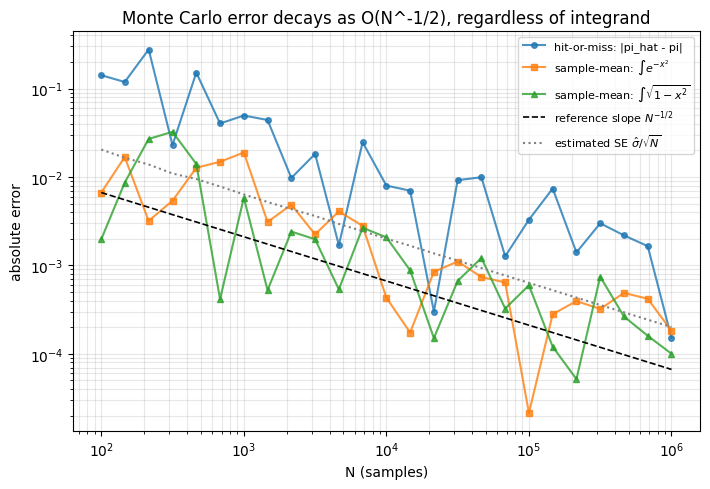

In [3]:
# --- 수렴 그래프: error vs N (log-log), 기울기 -1/2 기준선 ---
Ns_fine = np.unique(np.logspace(2, 6, 25).astype(int))
err_pi, err_g1, err_g2, se_g1 = [], [], [], []
for N in Ns_fine:
    err_pi.append(abs(mc_pi(N)[0] - np.pi))
    e1, s1 = mc_mean(g1, N); err_g1.append(abs(e1 - I1)); se_g1.append(s1)
    err_g2.append(abs(mc_mean(g2, N)[0] - I2))

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.loglog(Ns_fine, err_pi, "o-", ms=4, alpha=0.8, label="hit-or-miss: |pi_hat - pi|")
ax.loglog(Ns_fine, err_g1, "s-", ms=4, alpha=0.8, label=r"sample-mean: $\int e^{-x^2}$")
ax.loglog(Ns_fine, err_g2, "^-", ms=4, alpha=0.8, label=r"sample-mean: $\int\sqrt{1-x^2}$")
ref = err_g1[0] * (Ns_fine / Ns_fine[0])**(-0.5)
ax.loglog(Ns_fine, ref, "k--", lw=1.2, label=r"reference slope $N^{-1/2}$")
ax.loglog(Ns_fine, se_g1, ":", color="gray", label=r"estimated SE $\hat\sigma/\sqrt{N}$")
ax.set_xlabel("N (samples)"); ax.set_ylabel("absolute error")
ax.set_title("Monte Carlo error decays as O(N^-1/2), regardless of integrand")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

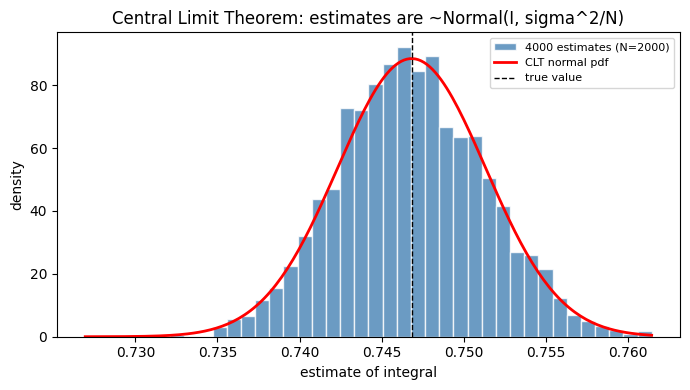

경험적 표준편차 = 4.48308e-03,  이론 sigma/sqrt(N) = 4.51108e-03


In [4]:
# --- CLT 확인: 고정 N에서 추정을 R번 반복 → 정규분포 ---
N_fix, R = 2000, 4000
ests = np.array([mc_mean(g1, N_fix)[0] for _ in range(R)])
emp_sd = ests.std(ddof=1)
sigma2 = (g1(rng.random(2_000_000))**2).mean() - I1**2
theo_sd = np.sqrt(sigma2 / N_fix)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ests, bins=40, density=True, color="steelblue", edgecolor="white", alpha=0.8,
        label=f"{R} estimates (N={N_fix})")
xs = np.linspace(ests.min(), ests.max(), 200)
ax.plot(xs, np.exp(-(xs - I1)**2 / (2*theo_sd**2)) / (theo_sd*np.sqrt(2*np.pi)),
        "r-", lw=2, label="CLT normal pdf")
ax.axvline(I1, color="k", ls="--", lw=1, label="true value")
ax.set_xlabel("estimate of integral"); ax.set_ylabel("density")
ax.set_title("Central Limit Theorem: estimates are ~Normal(I, sigma^2/N)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"경험적 표준편차 = {emp_sd:.5e},  이론 sigma/sqrt(N) = {theo_sd:.5e}")


## 4. 결과 해석

1. **표**: $N$ 이 100배 커질 때마다(예: $10^2\!\to\!10^4$) 참오차와 표준오차가 대략 **10배**씩
   줄어든다 — 정확히 $\sqrt{N}$ 법칙($\sqrt{100}=10$). 참오차는 대체로 $1\text{–}2\,\mathrm{SE}$ 안에 들어온다.
2. **수렴 그래프**: 세 추정량 모두 기울기 $-1/2$ 의 점선과 평행하게 떨어진다.
   특히 $g_2=\sqrt{1-x^2}$ 는 $x=1$ 에서 도함수가 발산해 사다리꼴/심프슨이 차수 손실을 겪지만,
   **몬테카를로 기울기는 그대로 $-1/2$** — *적분함수의 매끄러움에 무관*함을 보여준다.
3. **추정 SE**(회색 점선)가 실제 오차의 포락선과 잘 겹친다 → 표본분산만으로 오차 막대를 줄 수 있다.
4. **CLT 히스토그램**: 반복 추정의 분포가 정규곡선과 일치하고, 경험적 표준편차가 이론값 $\sigma/\sqrt N$ 과 부합.

### 결론
> **몬테카를로 적분의 오차는 적분함수가 얼마나 매끄럽든 $\mathcal{O}(N^{-1/2})$ 로만 줄어든다.**
> 1차원에서는 심프슨($N^{-4}$)에 한참 뒤지지만, 이 수렴률이 *차원과 무관*하다는 점이
> 고차원에서 결정론적 격자법을 역전시키는 결정적 강점이 된다.

### 다음 문제 연결
- **CE 10.1.3**: $N^{-1/2}$ 의 *상수* $\sigma$ 자체를 줄이는 **분산 감소(variance reduction)** —
  대조변량(antithetic), 층화표집(stratified), 중요도표집(importance) — 으로 같은 $N$ 에서 오차를 줄인다.
